<a href="https://colab.research.google.com/github/mhmmdrdhiansyah/data-science-2026/blob/main/pertemuan5_muhammad_ardhiansyah_240401020092.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

nama : Muhammad ardhianyshah

nim : 240401020092

kelas : IF403

--- Dimensi & Tipe Data Fitur ---
(144, 3) year             int64
month         category
passengers       int64
dtype: object

--- Ringkasan Statistik Deskriptif ---
          year  passengers
count   144.00      144.00
mean   1954.50      280.30
std       3.46      119.97
min    1949.00      104.00
25%    1951.75      180.00
50%    1954.50      265.50
75%    1957.25      360.50
max    1960.00      622.00


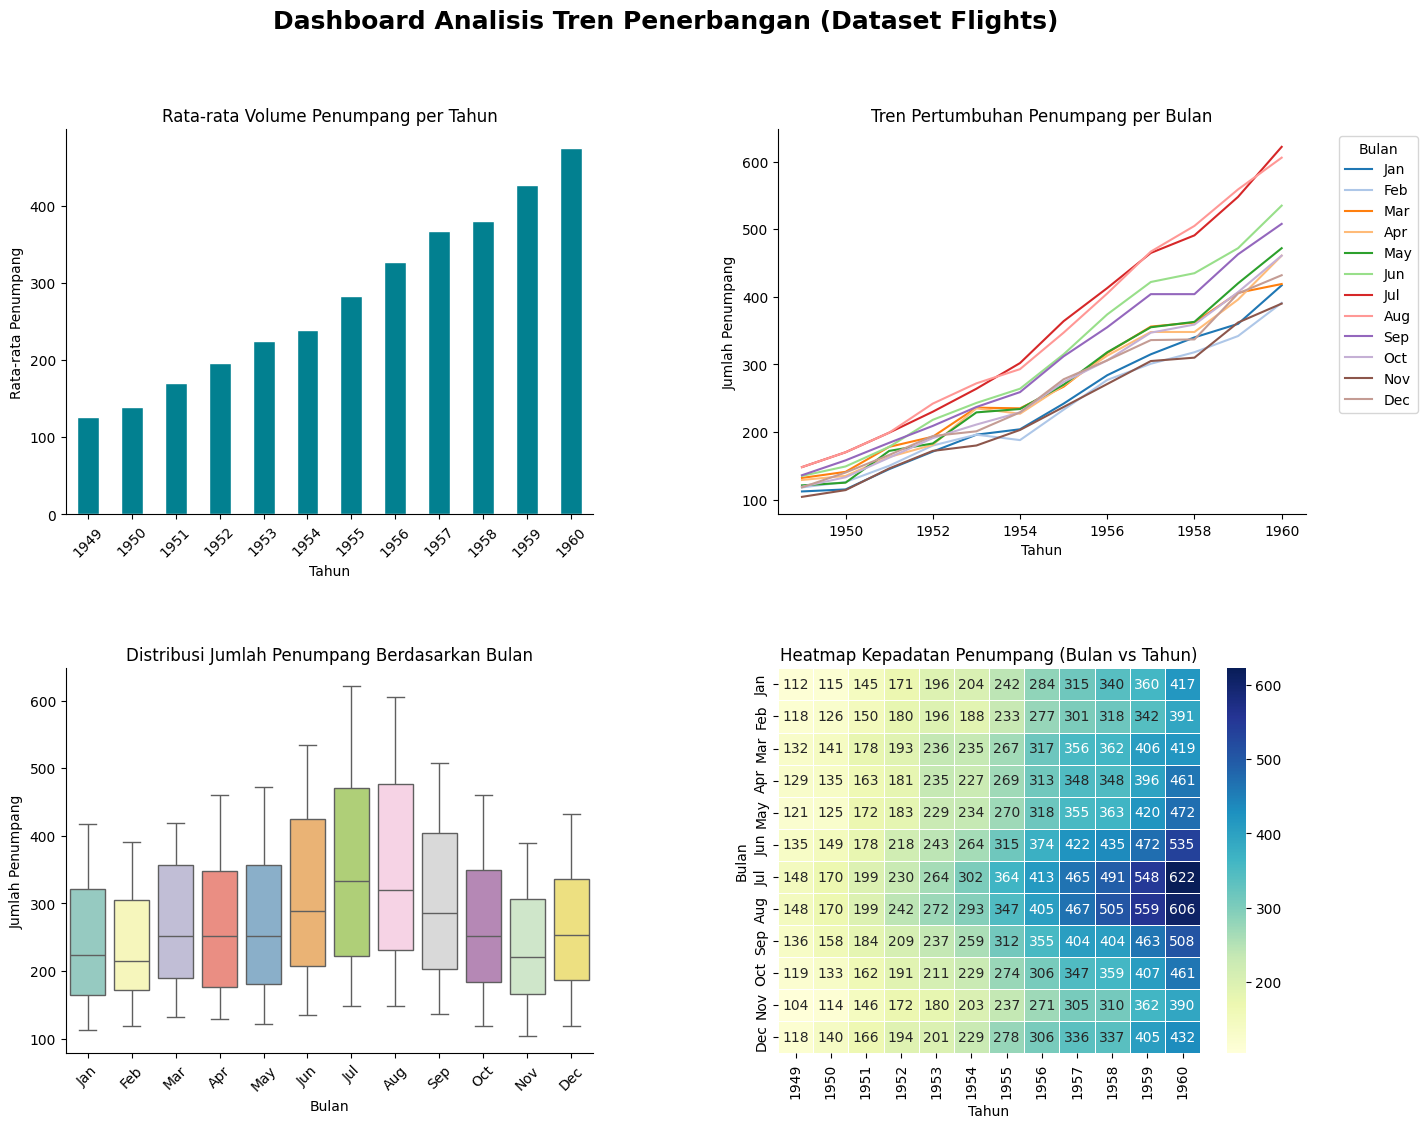

Dashboard sukses dibuat dan disimpan sebagai dashboard_flights.png


In [9]:
# ── TEMPLATE DASHBOARD VISUALISASI STATIS — DATASET FLIGHTS ──
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns

# ── 1. LOAD & INSPECT DATASET ──────────────────────────────────────────
# Memuat dataset penerbangan sesuai panduan Modul Pertemuan 5
df = sns.load_dataset('flights')
print("--- Dimensi & Tipe Data Fitur ---")
print(df.shape, df.dtypes)
print("\n--- Ringkasan Statistik Deskriptif ---")
print(df.describe().round(2))

# ── 2. SETUP FIGURE LAYOUT ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Tren Penerbangan (Dataset Flights)',
             fontsize=18, fontweight='bold', y=0.98)

# Grid 2 x 2 subplot menggunakan GridSpec
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0]) # kiri atas
ax2 = fig.add_subplot(gs[0, 1]) # kanan atas
ax3 = fig.add_subplot(gs[1, 0]) # kiri bawah
ax4 = fig.add_subplot(gs[1, 1]) # kanan bawah

# ── 3. GRAFIK 1: Bar Chart (Rata-rata Penumpang per Tahun) ─────────────
# Agregasi data untuk menghitung rata-rata penumpang tiap tahunnya
avg_by_year = df.groupby('year', observed=True)['passengers'].mean()
avg_by_year.plot(kind='bar', ax=ax1, color='#028090', edgecolor='white')
ax1.set_title('Rata-rata Volume Penumpang per Tahun')
ax1.set_xlabel('Tahun')
ax1.set_ylabel('Rata-rata Penumpang')
ax1.tick_params(axis='x', rotation=45) # Memiringkan teks sumbu X agar rapi
ax1.spines[['top','right']].set_visible(False)

# ── 4. GRAFIK 2: Line Chart (Tren Kenaikan Penumpang dari Waktu ke Waktu) ──
# Menghubungkan titik pertumbuhan untuk melihat pola seasonal tahunan
sns.lineplot(data=df, x='year', y='passengers', hue='month', palette='tab20', ax=ax2)
ax2.set_title('Tren Pertumbuhan Penumpang per Bulan')
ax2.set_xlabel('Tahun')
ax2.set_ylabel('Jumlah Penumpang')
# Menaruh kotak legenda di luar grafik agar tidak menutupi garis tren
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Bulan')
ax2.spines[['top','right']].set_visible(False)

# ── 5. GRAFIK 3: Boxplot (Karakteristik Penumpang Berdasarkan Bulan) ─────
# Melihat bulan-bulan sibuk (peak season) liburan sepanjang tahun
sns.boxplot(data=df, x='month', y='passengers', hue='month', palette='Set3', legend=False, ax=ax3)
ax3.set_title('Distribusi Jumlah Penumpang Berdasarkan Bulan')
ax3.set_xlabel('Bulan')
ax3.set_ylabel('Jumlah Penumpang')
ax3.tick_params(axis='x', rotation=45)
ax3.spines[['top','right']].set_visible(False)

# ── 6. GRAFIK 4: Heatmap Kerapatan (Matriks Tahun vs Bulan) ──────────────
# Sesuai saran referensi modul untuk flights: mereduksi data menjadi tabel silang
flights_pivot = df.pivot(index="month", columns="year", values="passengers")
sns.heatmap(flights_pivot, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5, ax=ax4)
ax4.set_title('Heatmap Kepadatan Penumpang (Bulan vs Tahun)')
ax4.set_xlabel('Tahun')
ax4.set_ylabel('Bulan')

# ── 7. EKSPOR DASHBOARD ──────────────────────────────────────────────────
plt.savefig('dashboard_flights.png', dpi=150, bbox_inches='tight')
plt.show()

print('Dashboard sukses dibuat dan disimpan sebagai dashboard_flights.png')

Pada Pertemuan 5 mengenai Visualisasi Data, saya telah mempelajari bagaimana menyajikan informasi statistik secara grafis, komunikatif, dan bermakna agar data tidak sekadar menjadi tumpukan angka mentah. Fokus utama dari materi ini adalah menyeimbangkan aspek estetika dan ketepatan penyajian dengan mematuhi lima prinsip visualisasi efektif, yaitu kejelasan (clarity), akurasi skala (accuracy), efisiensi pembacaan (efficiency), estetika warna (aesthetics), serta kesesuaian jenis bagan dengan tipe data yang dimiliki.

Secara teknis, saya belajar memahami arsitektur pembuatan grafik di Python menggunakan kombinasi kanvas utama (Figure) dan kapling area gambar (Axes) lewat pustaka Matplotlib dan GridSpec, yang memungkinkan penyusunan sebuah dasbor multi-plot statis yang rapi dan terorganisasi.

Melalui studi kasus Dataset Flights yang bertipe time-series, saya mengasah kemampuan untuk memilih visualisasi yang tepat, seperti menggunakan Line Chart untuk mendeteksi tren kenaikan volume dan pola musiman (seasonal) dari waktu ke waktu, serta memanfaatkan Heatmap Kerapatan berbasis tabel silang (pivot table) untuk memetakan kepadatan interaksi antar-variabel secara intuitif.
